# Credit Scoring in FHE

In this notebook, we build and evaluate a model that predicts the chance that a given loan applicant defaults on loan repayment while keeping the user's data private using Fully Homomorphic Encryption (FHE). It is strongly inspired from an [existing notebook](https://www.kaggle.com/code/ajay1735/my-credit-scoring-model) found on Kaggle, which uses the [Home Equity (HMEQ) dataset](https://www.kaggle.com/code/ajay1735/my-credit-scoring-model/input). In addition, we compare the performance between the original scikit-learn models and their Concrete ML equivalent. 

### Import libraries

In [1]:
import time

import pandas as pd
from sklearn.ensemble import RandomForestClassifier as SklearnRandomForestClassifier
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Import models from scikit-learn and XGBoost
from sklearn.tree import DecisionTreeClassifier as SklearnDecisionTreeClassifier
from xgboost import XGBClassifier as SklearnXGBoostClassifier

# Import models from Concrete ML
from concrete.ml.sklearn import DecisionTreeClassifier as ConcreteDecisionTreeClassifier
from concrete.ml.sklearn import LogisticRegression as ConcreteLogisticRegression
from concrete.ml.sklearn import RandomForestClassifier as ConcreteRandomForestClassifier
from concrete.ml.sklearn import XGBClassifier as ConcreteXGBoostClassifier

CONCRETE_ML_MODELS = [
    ConcreteDecisionTreeClassifier,
    ConcreteLogisticRegression,
    ConcreteRandomForestClassifier,
    ConcreteXGBoostClassifier,
]

### Load the HMEQ dataset

In [ ]:
# Reading the dataset
df = pd.read_csv("notebooks/hmeq.csv")
print(df.columns)

FileNotFoundError: [Errno 2] No such file or directory: 'hmeq.csv'

### Clean the dataset
Further details about dataset cleaning can be found the [original notebook](https://www.kaggle.com/code/ajay1735/my-credit-scoring-model).

In [ ]:
# Replace missing values
df["REASON"].fillna(value="DebtCon", inplace=True)
df["JOB"].fillna(value="Other", inplace=True)
df["DEROG"].fillna(value=0, inplace=True)
df["DELINQ"].fillna(value=0, inplace=True)

df.fillna(value=df.mean(numeric_only=True), inplace=True)

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0000,39025.000000,HomeImp,Other,10.500000,0.00000,0.000000,94.366667,1.000000,9.000000,33.779915
1,1,1300,70053.0000,68400.000000,HomeImp,Other,7.000000,0.00000,2.000000,121.833333,0.000000,14.000000,33.779915
2,1,1500,13500.0000,16700.000000,HomeImp,Other,4.000000,0.00000,0.000000,149.466667,1.000000,10.000000,33.779915
3,1,1500,73760.8172,101776.048741,NaN,NaN,8.922268,0.25457,0.449442,179.766275,1.186055,21.296096,33.779915
4,0,1700,97800.0000,112000.000000,HomeImp,Office,3.000000,0.00000,0.000000,93.333333,0.000000,14.000000,33.779915
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5955,0,88900,57264.0000,90185.000000,DebtCon,Other,16.000000,0.00000,0.000000,221.808718,0.000000,16.000000,36.112347
5956,0,89000,54576.0000,92937.000000,DebtCon,Other,16.000000,0.00000,0.000000,208.692070,0.000000,15.000000,35.859971
5957,0,89200,54045.0000,92924.000000,DebtCon,Other,15.000000,0.00000,0.000000,212.279697,0.000000,15.000000,35.556590
5958,0,89800,50370.0000,91861.000000,DebtCon,Other,14.000000,0.00000,0.000000,213.892709,0.000000,16.000000,34.340882


In [ ]:
df.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0000,39025.000000,HomeImp,Other,10.500000,0.00000,0.000000,94.366667,1.000000,9.000000,33.779915
1,1,1300,70053.0000,68400.000000,HomeImp,Other,7.000000,0.00000,2.000000,121.833333,0.000000,14.000000,33.779915
2,1,1500,13500.0000,16700.000000,HomeImp,Other,4.000000,0.00000,0.000000,149.466667,1.000000,10.000000,33.779915
3,1,1500,73760.8172,101776.048741,NaN,NaN,8.922268,0.25457,0.449442,179.766275,1.186055,21.296096,33.779915
4,0,1700,97800.0000,112000.000000,HomeImp,Office,3.000000,0.00000,0.000000,93.333333,0.000000,14.000000,33.779915


In [ ]:
# Remove features BAD, JOB and REASON from the input feature set
x_basic = df.drop(columns=["BAD", "JOB", "REASON"])
y = df["BAD"]

### Credit scoring with Concrete ML
In the following step, we first define the scikit-learn models found in the original notebook and build their FHE equivalent model using Concrete ML. Then, we evaluate and compare them side by side using several metrics (accuracy, F1 score, recall, precision). For Concrete ML models, their inference's execution time is also provided when done in FHE.

In [ ]:
def evaluate(
    model, x, y, test_size=0.33, show_circuit=False, predict_in_fhe=True, fhe_samples=None
):
    """Evaluate the given model using several metrics.

    The model is evaluated using the following metrics: accuracy, F1 score, precision, recall.
    For Concrete ML models, the inference's execution time is provided when done in FHE.

    Args:
        model: The initialized model to consider.
        x: The input data to consider.
        y: The target data to consider.
        test_size: The proportion to use for the test data. Default to 0.33.
        show_circuit: If the FHE circuit should be printed for Concrete ML models. Default to False.
        predict_in_fhe: If the inference should be executed in FHE for Concrete ML models. Else, it
            will only be simulated.
        fhe_sample: The number of samples to consider for evaluating the inference of Concrete ML
            models if predict_in_fhe is set to True. If None, the complete test set is used. Default
            to None.
    """
    evaluation_result = {}

    is_concrete_ml = model.__class__ in CONCRETE_ML_MODELS

    name = model.__class__.__name__ + (" (Concrete ML)" if is_concrete_ml else " (sklearn)")

    evaluation_result["name"] = name

    print(f"Evaluating model {name}")

    # Split the data into test and train sets. Stratify is used to make sure that the test set
    # contains some representative class distribution for targets
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, stratify=y, test_size=test_size, random_state=1
    )
    test_length = len(x_test)

    evaluation_result["Test samples"] = test_length

    evaluation_result["n_bits"] = model.n_bits if is_concrete_ml else None

    # Normalization pipeline
    model = Pipeline(
        [
            ("preprocessor", StandardScaler()),
            ("model", model),
        ]
    )

    # Train the model
    model.fit(x_train, y_train)

    # Run the prediction and store its execution time
    y_pred = model.predict(x_test)

    # Evaluate the model
    # For Concrete ML models, this will execute the (quantized) inference in the clear
    evaluation_result["Accuracy (clear)"] = accuracy_score(y_test, y_pred)
    evaluation_result["F1 (clear)"] = f1_score(y_test, y_pred, average="macro")
    evaluation_result["Precision (clear)"] = precision_score(y_test, y_pred, average="macro")
    evaluation_result["Recall (clear)"] = recall_score(y_test, y_pred, average="macro")

    # If the model is from Concrete ML
    if is_concrete_ml:

        print("Compile the model")

        # Compile the model using the training data
        circuit = model["model"].compile(x_train)  # pylint: disable=no-member

        # Print the FHE circuit if needed
        if show_circuit:
            print(circuit)

        # Retrieve the circuit's max bit-width
        evaluation_result["max bit-width"] = circuit.graph.maximum_integer_bit_width()

        print("Predict (simulated)")

        # Run the prediction in the clear using FHE simulation, store its execution time and
        # evaluate the accuracy score
        y_pred_simulate = model.predict(x_test, fhe="simulate")

        evaluation_result["Accuracy (simulated)"] = accuracy_score(y_test, y_pred_simulate)

        # Run the prediction in FHE, store its execution time and evaluate the accuracy score
        if predict_in_fhe:
            if fhe_samples is not None:
                x_test = x_test[0:fhe_samples]
                y_test = y_test[0:fhe_samples]
                test_length = fhe_samples

            evaluation_result["FHE samples"] = test_length

            print("Predict (FHE)")

            before_time = time.time()
            y_pred_fhe = model.predict(x_test, fhe="execute")
            evaluation_result["FHE execution time (second per sample)"] = (
                time.time() - before_time
            ) / test_length

            evaluation_result["Accuracy (FHE)"] = accuracy_score(y_test, y_pred_fhe)

    print("Done !\n")

    return evaluation_result

### Run the evaluation
In the following, we evaluate several types of classifiers : logistic regression, decision tree, random forest and XGBoost.

In [ ]:
results = []

# Define the test size proportion
test_size = 0.2

# For testing FHE execution locally, define the number of inference to run. If None, the complete
# test set is used
fhe_samples = 5   # limit encrypted inference to 5 samples to speed up experimentation(change) 

# Logistic regression
results.append(evaluate(SklearnLogisticRegression(), x_basic, y, test_size=test_size))
results.append(evaluate(ConcreteLogisticRegression(), x_basic, y, test_size=test_size))

# Define the initialization parameters for tree-based models
init_params_dt = {"max_depth": 3}   # shallower tree reduces FHE runtime dramatically(change)
init_params_rf = {"max_depth": 3, "n_estimators": 3}   # smaller forest makes encrypted inference feasible(change)
init_params_xgb = {"max_depth": 3, "n_estimators": 3}   # reduces FHE cost while keeping model functional(change)
init_params_cml = {"n_bits": 6}  # higher precision quantization for accuracy comparison(change)

# Determine the type of models to evaluate
use_dt = True
use_rf = True
use_xgb = True
predict_in_fhe = True

# Decision tree models
if use_dt:

    # Scikit-Learn model
    results.append(
        evaluate(
            SklearnDecisionTreeClassifier(**init_params_dt),
            x_basic,
            y,
            test_size=test_size,
        )
    )

    # Concrete ML model
    results.append(
        evaluate(
            ConcreteDecisionTreeClassifier(**init_params_dt, **init_params_cml),
            x_basic,
            y,
            test_size=test_size,
            predict_in_fhe=predict_in_fhe,
            fhe_samples=fhe_samples,
        )
    )

# Random Forest
if use_rf:

    # Scikit-Learn model
    results.append(
        evaluate(
            SklearnRandomForestClassifier(**init_params_rf),
            x_basic,
            y,
            test_size=test_size,
        )
    )

    # Concrete ML model
    results.append(
        evaluate(
            ConcreteRandomForestClassifier(**init_params_rf, **init_params_cml),
            x_basic,
            y,
            test_size=test_size,
            predict_in_fhe=predict_in_fhe,
            fhe_samples=fhe_samples,
        )
    )

# XGBoost
if use_xgb:

    # Scikit-Learn model
    results.append(
        evaluate(
            SklearnXGBoostClassifier(**init_params_xgb),
            x_basic,
            y,
            test_size=test_size,
        )
    )

    # Concrete ML model
    results.append(
        evaluate(
            ConcreteXGBoostClassifier(**init_params_xgb, **init_params_cml),
            x_basic,
            y,
            test_size=test_size,
            predict_in_fhe=predict_in_fhe,
            fhe_samples=fhe_samples,
        )
    )

Evaluating model LogisticRegression (sklearn)
Done !

Evaluating model LogisticRegression (Concrete ML)
Compile the model
Predict (simulated)
Predict (FHE)
Done !

Evaluating model DecisionTreeClassifier (sklearn)
Done !

Evaluating model DecisionTreeClassifier (Concrete ML)
Compile the model
Predict (simulated)
Predict (FHE)
Done !

Evaluating model RandomForestClassifier (sklearn)
Done !

Evaluating model RandomForestClassifier (Concrete ML)
Compile the model
Predict (simulated)
Predict (FHE)
Done !

Evaluating model XGBClassifier (sklearn)
Done !

Evaluating model XGBClassifier (Concrete ML)
Compile the model
Predict (simulated)
Predict (FHE)
Done !



### Compare the models

Let's compare the models' performance in a pandas Dataframe. We can see that with only a few bits of quantization, the Concrete models perform as well as their scikit-learn equivalent. More precisely, the small differences that can be observed are only the result of quantization: running the inference in FHE does not impact the accuracy score.

In [ ]:
pd.set_option("display.precision", 3)

results_dataframe = pd.DataFrame(results)
results_dataframe.fillna("")
results_dataframe

,name,Test samples,n_bits,Accuracy (clear),F1 (clear),Precision (clear),Recall (clear),max bit-width,Accuracy (simulated),FHE samples,FHE execution time (second per sample),Accuracy (FHE)
0,LogisticRegression (sklearn),1192,NaN,0.823,0.620,0.749,0.601,NaN,NaN,NaN,NaN,NaN
1,LogisticRegression (Concrete ML),1192,8.0,0.823,0.622,0.747,0.602,18.0,0.823,1192.0,0.003,0.823
2,DecisionTreeClassifier (sklearn),1192,NaN,0.860,0.711,0.859,0.671,NaN,NaN,NaN,NaN,NaN
3,DecisionTreeClassifier (Concrete ML),1192,6.0,0.816,0.584,0.738,0.575,8.0,0.816,5.0,1.146,0.600
4,RandomForestClassifier (sklearn),1192,NaN,0.813,0.547,0.750,0.552,NaN,NaN,NaN,NaN,NaN
5,RandomForestClassifier (Concrete ML),1192,6.0,0.820,0.615,0.735,0.597,8.0,0.820,5.0,1.160,0.800
6,XGBClassifier (sklearn),1192,NaN,0.862,0.730,0.838,0.692,NaN,NaN,NaN,NaN,NaN
7,XGBClassifier (Concrete ML),1192,6.0,0.851,0.706,0.808,0.672,8.0,0.851,5.0,1.563,0.800


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_basic, y, stratify=y, test_size=0.33, random_state=1
)

x_train.shape, x_test.shape

((3993, 10), (1967, 10))

In [ ]:
import time
import pandas as pd

depth_values = [2, 3]
n_bits_values = [3, 6]

dt_grid_results = []

for depth in depth_values:
    for n_bits in n_bits_values:
        print(f"Running DecisionTree with max_depth={depth}, n_bits={n_bits}")

        # 1) Train sklearn DecisionTree
        from sklearn.tree import DecisionTreeClassifier
        dt_clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
        dt_clf.fit(x_train, y_train)

        # 2) Wrap into Concrete-ML model
        from concrete.ml.sklearn import DecisionTreeClassifier as CMLDecisionTreeClassifier

        cml_dt = CMLDecisionTreeClassifier(
            max_depth=depth,
            n_bits=n_bits,
        )

        # 3) Fit Concrete-ML model
        cml_dt.fit(x_train, y_train)

        # 4) Compile the model (required for simulate/execute)
        cml_dt.compile(x_train)

        # 5) Clear accuracy
        y_pred_clear = cml_dt.predict(x_test)
        acc_clear = (y_pred_clear == y_test).mean()

        # 6) Simulated FHE accuracy
        y_pred_sim = cml_dt.predict(x_test, fhe="simulate")
        acc_sim = (y_pred_sim == y_test).mean()

        # 7) Real FHE on a subset
        fhe_samples = 5
        x_fhe = x_test[:fhe_samples]

        start = time.time()
        y_pred_fhe = cml_dt.predict(x_fhe, fhe="execute")
        end = time.time()

        acc_fhe = (y_pred_fhe == y_test[:fhe_samples]).mean()
        time_per_sample = (end - start) / fhe_samples

        # 8) Store results
        dt_grid_results.append({
            "max_depth": depth,
            "n_bits": n_bits,
            "accuracy_clear": acc_clear,
            "accuracy_simulated": acc_sim,
            "accuracy_fhe": acc_fhe,
            "fhe_time_per_sample": time_per_sample,
        })

dt_grid_df = pd.DataFrame(dt_grid_results)
dt_grid_df

Running DecisionTree with max_depth=2, n_bits=3
Running DecisionTree with max_depth=2, n_bits=6
Running DecisionTree with max_depth=3, n_bits=3
Running DecisionTree with max_depth=3, n_bits=6


,max_depth,n_bits,accuracy_clear,accuracy_simulated,accuracy_fhe,fhe_time_per_sample
0,2,3,0.811,0.811,0.8,0.249
1,2,6,0.826,0.826,0.8,0.815
2,3,3,0.815,0.815,0.6,0.289
3,3,6,0.852,0.852,0.8,0.867


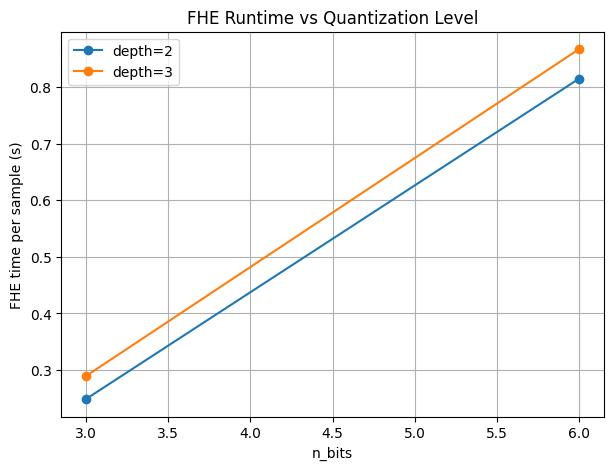

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

for depth in dt_grid_df["max_depth"].unique():
    subset = dt_grid_df[dt_grid_df["max_depth"] == depth]
    plt.plot(subset["n_bits"], subset["fhe_time_per_sample"], marker="o", label=f"depth={depth}")

plt.xlabel("n_bits")
plt.ylabel("FHE time per sample (s)")
plt.title("FHE Runtime vs Quantization Level")
plt.grid(True)
plt.legend()
plt.show()

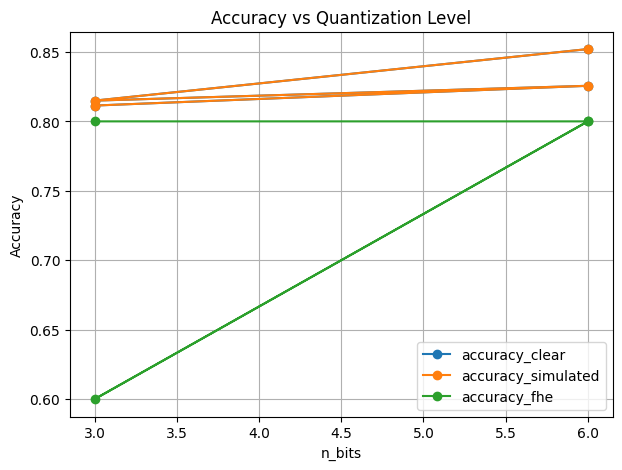

In [ ]:
plt.figure(figsize=(7,5))

for metric in ["accuracy_clear", "accuracy_simulated", "accuracy_fhe"]:
    plt.plot(dt_grid_df["n_bits"], dt_grid_df[metric], marker="o", label=metric)

plt.xlabel("n_bits")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Quantization Level")
plt.grid(True)
plt.legend()
plt.show()

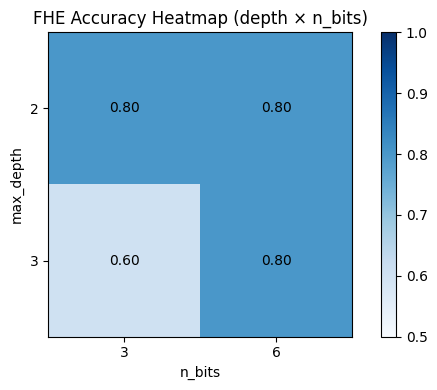

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare the data manually
depths = [2, 3]
n_bits = [3, 6]

# Accuracy values from your table
accuracy_matrix = np.array([
    [0.80, 0.80],  # depth = 2
    [0.60, 0.80],  # depth = 3
])

fig, ax = plt.subplots(figsize=(6, 4))

# Create heatmap
cax = ax.imshow(accuracy_matrix, cmap="Blues", vmin=0.5, vmax=1.0)

# Add text annotations
for i in range(len(depths)):
    for j in range(len(n_bits)):
        acc = accuracy_matrix[i, j]
        ax.text(j, i, f"{acc:.2f}", ha="center", va="center", color="black")

# Set axis labels and ticks
ax.set_xticks(np.arange(len(n_bits)))
ax.set_yticks(np.arange(len(depths)))
ax.set_xticklabels(n_bits)
ax.set_yticklabels(depths)
ax.set_xlabel("n_bits")
ax.set_ylabel("max_depth")
ax.set_title("FHE Accuracy Heatmap (depth × n_bits)")

# Add colorbar
fig.colorbar(cax)

plt.tight_layout()
plt.show()

In [ ]:
### Dataset Scaling Experiment
# Testing how FHE inference time changes with training dataset size

import time
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from concrete.ml.sklearn import DecisionTreeClassifier as CMLDecisionTreeClassifier

# Use a fixed configuration for fair comparison
FIXED_DEPTH = 3
FIXED_N_BITS = 6

# Test different dataset sizes
dataset_sizes = [500, 1000, 3000, 5960]  # 5960 is your full dataset
scaling_results = []

for n_samples in dataset_sizes:
    print(f"\nTesting with {n_samples} samples...")
    
    # Sample from training data
    x_train_subset = x_train[:n_samples]
    y_train_subset = y_train[:n_samples]
    
    # Train Concrete-ML model
    cml_dt = CMLDecisionTreeClassifier(
        max_depth=FIXED_DEPTH,
        n_bits=FIXED_N_BITS,
    )
    cml_dt.fit(x_train_subset, y_train_subset)
    cml_dt.compile(x_train_subset)
    
    # Test on same 5 FHE samples for consistency
    fhe_samples = 5
    x_fhe = x_test[:fhe_samples]
    
    start = time.time()
    y_pred_fhe = cml_dt.predict(x_fhe, fhe="execute")
    end = time.time()
    
    time_per_sample = (end - start) / fhe_samples
    
    scaling_results.append({
        "training_samples": n_samples,
        "fhe_time_per_sample": time_per_sample,
    })
    
    print(f"FHE time per sample: {time_per_sample:.3f}s")

scaling_df = pd.DataFrame(scaling_results)
print("\n=== Scaling Results ===")
scaling_df


Testing with 500 samples...


NameError: name 'x_train' is not defined

In [ ]:
### Plot: Dataset Size vs FHE Inference Time

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(scaling_df["training_samples"], scaling_df["fhe_time_per_sample"], 
         marker='o', linewidth=2, markersize=8, color='#2E86AB')
plt.xlabel("Training Dataset Size (samples)", fontsize=12)
plt.ylabel("FHE Inference Time per Sample (s)", fontsize=12)
plt.title("FHE Inference Time vs Training Dataset Size", fontsize=14, pad=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot_scaling_vs_dataset_size.png", dpi=150, bbox_inches='tight')
plt.show()

print("✓ Plot saved as 'plot_scaling_vs_dataset_size.png'")

In [ ]:
### Dataset Statistics and Class Balance

import pandas as pd
import numpy as np

print("=== Dataset Statistics ===\n")
print(f"Total samples: {len(y)}")
print(f"Training samples: {len(y_train)}")
print(f"Test samples: {len(y_test)}")
print(f"Number of features: {x_train.shape[1]}")

print(f"\n=== Class Distribution ===\n")
print("Full dataset:")
print(pd.Series(y).value_counts().sort_index())

print("\nProportions:")
proportions = pd.Series(y).value_counts(normalize=True).sort_index()
for label, prop in proportions.items():
    print(f"Class {label}: {prop:.1%}")

print("\nTrain/Test split maintains balance:")
print(f"Train - Class 0: {(y_train == 0).sum()}, Class 1: {(y_train == 1).sum()}")
print(f"Test  - Class 0: {(y_test == 0).sum()}, Class 1: {(y_test == 1).sum()}")